# Preparation

* ใช้ DataFrame จาก pandas จัดการข้อมูล
```
import pandas as pd
```
* ใช้ KMeans จาก sklearn.cluster เพื่อทำ Clustering
```
from sklearn.cluster import KMeans
```
* (optional) ใช้ matplotlib.pyplot ในการวาดกราฟ
```
import matplotlib.pyplot as plt
```
* ใช้ Elbow Method ในการหาจำนวนกลุ่ม
```
from yellowbrick.cluster import KElbowVisualizer
```

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer

# **Lab-1** Customer Segmentation

## สร้าง DataFrame เพื่อจัดการชุดข้อมูล

1.   สร้างชุดข้อมูลจากตัวอย่างในสไลด์
```
{
        'age': [42, 18, 23, 49, 37, 51, 40, 20],
        'eng': [7, 3, 2, 1, 7, 1, 6, 4]
}
```

In [2]:
{
        'age': [42, 18, 23, 49, 37, 51, 40, 20],
        'eng': [7, 3, 2, 1, 7, 1, 6, 4]
}

{'age': [42, 18, 23, 49, 37, 51, 40, 20], 'eng': [7, 3, 2, 1, 7, 1, 6, 4]}

2.   สร้าง DataFrame จากชุดข้อมูล
```
pd.DataFrame()
```

In [44]:
# data = {
#     'Medicine': ['a', 'b', 'd', 'd', 'e', 'f'],
#     'pH-Index': [1, 2, 3, 5, 6, 4],
#     'Weight': [4, 3, 4, 1, 2, 1]
# }

data = {
        'age': [42, 18, 23, 49, 37, 51, 40, 20],
        'eng': [7, 3, 2, 1, 7, 1, 6, 4]
}

# df = pd.DataFrame(data).set_index("Medicine")
df = pd.DataFrame(data)

print(df)

   age  eng
0   42    7
1   18    3
2   23    2
3   49    1
4   37    7
5   51    1
6   40    6
7   20    4


## สร้างโมเดลของ k-means
```
KMeans(n_clusters=?)
```

In [45]:
kmean = KMeans(n_clusters=3,random_state=42)
kmean

KMeans(n_clusters=3, random_state=42)

## ให้ model เรียนรู้จากชุดข้อมูลใน DataFrame
```
fit()
```

In [46]:
kmean.fit(df)

KMeans(n_clusters=3, random_state=42)

## ดูผลการทำ Clustering

* Centroids
```
cluster_centers_
```

In [47]:
C_Center = kmean.cluster_centers_
C_Center

array([[20.33333333,  3.        ],
       [39.66666667,  6.66666667],
       [50.        ,  1.        ]])

* Labels
```
labels_
```

In [48]:
label = kmean.labels_

## (optional) วาดกราฟ
```
plt.scatter()
```

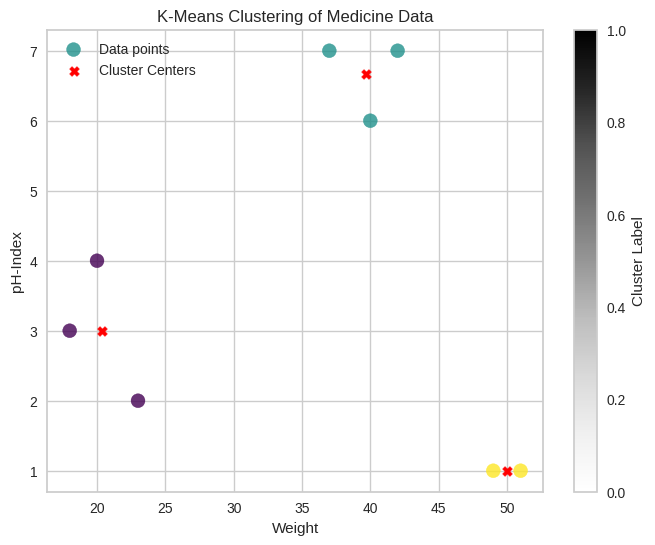

In [50]:
# plt.figure(figsize=(8, 6))
# plt.scatter(df['Weight'], df['pH-Index'], c=label, cmap='viridis', s=100, alpha=0.8, label='Data points')
# plt.scatter(C_Center[:, 1], C_Center[:, 0], s=50, c='red', marker='X', label='Cluster Centers')
# plt.xlabel('Weight')
# plt.ylabel('pH-Index')
# plt.title('K-Means Clustering of Medicine Data')
# plt.colorbar(label='Cluster Label')
# plt.legend()
# plt.grid(True)
# plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['eng'], c=label, cmap='viridis', s=100, alpha=0.8, label='Data points')
plt.scatter(C_Center[:, 0], C_Center[:, 1], s=50, c='red', marker='X', label='Cluster Centers')
plt.xlabel('Weight')
plt.ylabel('pH-Index')
plt.title('K-Means Clustering of Medicine Data')
plt.colorbar(label='Cluster Label')
plt.legend()
plt.grid(True)
plt.show()

## Add the cluster labels to the original data

In [19]:
df['Cluster_Label'] = label
display(df)

,pH-Index,Weight,Cluster_Label
Medicine,,,
a,1,4,0
b,2,3,0
d,3,4,2
d,5,1,1
e,6,2,1
f,4,1,1


## Within Cluster Sum Of Square
```
inertia_
```

In [24]:
print(kmean.inertia_)

3.6666666666666665


# **Lab-2** - Grains Clustering

ใช้ข้อมูลของธัญญพืชที่ให้มานี้ แสดงวิธีการทำ Clustering โดยหาจำนวนกลุ่มที่เหมาะสมที่สุด พร้อมทั้งอธิบายลักษณะของแต่ละกลุ่มที่ได้
```
{
    'sugar': [6, 8, 5, 0, 8, 10, 14, 8, 6, 5, 12, 1, 9, 7, 13],
    'cal': [70, 120, 70, 50, 110, 110, 110, 130, 90, 90, 120, 110, 120, 110, 110],
    'protein': [4, 3,4, 4, 2, 2, 2, 3, 2, 3, 1, 6, 1, 3, 1],
    'fat': [1, 5, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 3, 2, 1],
    'sodium': [130, 15, 260, 140, 200, 180, 125, 210, 200, 210, 220, 290, 210, 140, 180]
}
```

In [67]:
df2 = pd.DataFrame({
    'sugar': [6, 8, 5, 0, 8, 10, 14, 8, 6, 5, 12, 1, 9, 7, 13],
    'cal': [70, 120, 70, 50, 110, 110, 110, 130, 90, 90, 120, 110, 120, 110, 110],
    'protein': [4, 3,4, 4, 2, 2, 2, 3, 2, 3, 1, 6, 1, 3, 1],
    'fat': [1, 5, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 3, 2, 1],
    'sodium': [130, 15, 260, 140, 200, 180, 125, 210, 200, 210, 220, 290, 210, 140, 180]
})

df2

,sugar,cal,protein,fat,sodium
0,6,70,4,1,130
1,8,120,3,5,15
2,5,70,4,1,260
3,0,50,4,0,140
4,8,110,2,2,200
5,10,110,2,2,180
6,14,110,2,0,125
7,8,130,3,2,210
8,6,90,2,1,200
9,5,90,3,0,210


## Determining the number of clusters to be formed
* ใช้ Elbow Method ในการหาจำนวนกลุ่ม
```
from yellowbrick.cluster import KElbowVisualizer
```
* สร้างโมเดลของ KElbowVisualizer
```
KElbowVisualizer(KMeans(), k=(2, ?))
```
* ให้ model เรียนรู้และแสดงผลกราฟ Elbow
```
fit()
show()
```

In [64]:
from yellowbrick.cluster import KElbowVisualizer

KElbowVisualizer(ax=<Axes: >, estimator=KMeans(random_state=42), k=(2, 8))

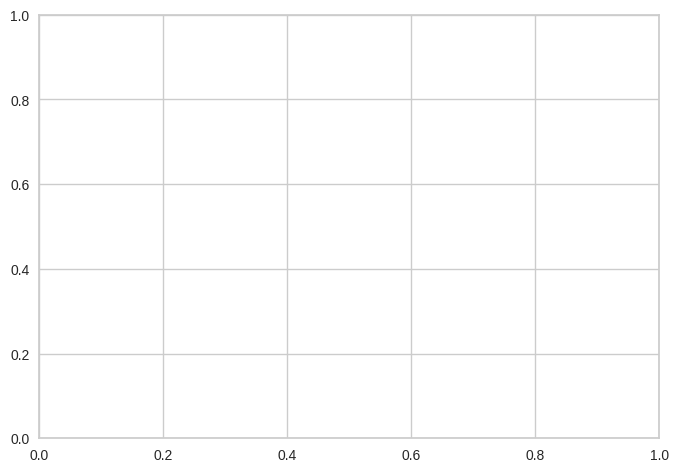

In [70]:
kmean2 = KElbowVisualizer(KMeans(random_state=42), k=(2,8))
kmean2

In [71]:
kmean2.fit(df2)
kmean2.show()

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [72]:
C_Center2 = kmean2.cluster_centers_
C_Center2

array([[  9.75, 115.  ,   2.  ,   1.75, 192.5 ],
       [  1.  , 110.  ,   6.  ,   2.  , 290.  ],
       [  8.  , 120.  ,   3.  ,   5.  ,  15.  ],
       [ 10.5 , 110.  ,   2.5 ,   1.  , 132.5 ],
       [  3.  ,  60.  ,   4.  ,   0.5 , 135.  ],
       [  5.  ,  70.  ,   4.  ,   1.  , 260.  ],
       [  8.  , 105.  ,   1.75,   1.5 , 210.  ]])

## Workshop: Implementing K-Means Clustering
* เลือกใช้จำนวนกลุ่ม k ที่เหมาะสม จัดกลุ่มธัญพืช และอธิบายผลลัพธ์ที่ได้

## สรุปคะแนน Performance เบื้องต้น

### Silhouette Score
```
from sklearn.metrics import silhouette_score
```
* คำนวณค่า Silhouette Score ของโมเดล
```
silhouette_score(X, labels)

### Davies-Bouldin Index (DBI)
```
from sklearn.metrics import davies_bouldin_score
```
* คำนวณค่า Davies-Bouldin Index (DBI) ของโมเดล
```
davies_bouldin_score(X, labels)
```

### Calinski-Harabasz Index (CHI)
```
from sklearn.metrics import calinski_harabasz_score
```
* คำนวณค่า Calinski-Harabasz Index (CHI) ของโมเดล
```
calinski_harabasz_score(X, labels)
```

## Comparing Clustering Performance เพื่อเลือกค่า k ที่เหมาะสม
* สร้าง list ของ [score, k]
* ทดลอง k = 2, 3, 4, 5, 6, ...
* สร้างโมเดล K-Means สำหรับค่า k นั้น ในแต่ละรอบ


### Silhouette Score


### Davies-Bouldin Index (DBI)


### Calinski-Harabasz Index (CHI)


## Refining Clustering Analysis:

* Define the number of clusters